In [1]:
import math
import logging
import time

from model import E3DensityModel, ResidualCorrectionModel

from torch.utils.data.dataloader import DataLoader

import torch

import glob
import os
import numpy as np
from tqdm import  tqdm
from torch.utils.data import DataLoader, random_split, Subset
# from torch.utils.data import DataLoader
from ase.db import connect
from utils_see_chg import DensityData, MyCollator
from transformers import AdamW, get_scheduler

random_seed = 42
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)


device = 'cuda:7'

model = E3DensityModel()
res_model = ResidualCorrectionModel(num_embeddings=300, embedding_dim=128)

num_train_epochs = 300
output_dir = './checkpoints'


# dict_test = {'atom_edges_displacement': torch.zeros(1 , 50, 3),
#              'num_atom_edges': torch.tensor(10).long().unsqueeze(0),
#              'num_nodes': torch.tensor(5).long().unsqueeze(0),
#              'atom_edges': torch.zeros(1, 50, 2).long(),
#              'atom_xyz': torch.zeros(1, 5, 3),
#              'nodes': torch.ones(5).long().unsqueeze(0),
#              'cell': torch.zeros(1, 3, 3),
#              'probe_xyz': torch.zeros(1, 500, 3),
#              'num_probes': torch.tensor(500).long().unsqueeze(0),
#              'probe_edges_displacement': torch.zeros(1, 500, 3),
#              'num_probe_edges': torch.tensor(500).long().unsqueeze(0),
#              'probe_edges': torch.zeros(1, 500, 2).long()
#              }


#mysql_url= 'mysql://root:@localhost:3306/temp_chg'
mysql_url = 'quick.db'
dataset = DensityData(mysql_url)
total_count = len(dataset)
print(f"Total count: {total_count}")
# train_count = int(0.8 * total_count)
# valid_count = int(0.1 * total_count)
# test_count = total_count - train_count - valid_count
# train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_count, valid_count, test_count])

# Access the last item from the test dataset
# last_index = dataset.indices[-1]
# last_example = dataset[last_index]


# checkpoint = torch.load('/data/chg/charge3net-main/checkpoints/xrd_best.pt', map_location='cpu')  # 加载 .pt 文件
# model.load_state_dict(checkpoint)
# model = model.to(device)

# checkpoint = torch.load('/data/chg/charge3net-main/models/charge3net_mp.pt', map_location='cpu')  # 加载 .pt 文件
# model.load_state_dict(checkpoint['model'])
# model = model.to(device)

checkpoint = torch.load('/data/chg/charge3net-main-suth/checkpoints_res/res_best_model.pt', map_location='cpu')  # 加载 .pt 文件
model.load_state_dict(checkpoint)
model = model.to(device)


checkpoint = torch.load('/data/chg/charge3net-main-suth/checkpoints_res/res_best.pt', map_location='cpu')  # 加载 .pt 文件
# print(checkpoint.keys())
res_model.load_state_dict(checkpoint)

res_model = res_model.to(device)

/home/cb/anaconda3/envs/mace/lib/python3.9/site-packages/torch/jit/_check.py:181: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn("The TorchScript type system doesn't support "


checkpoint directory created: ./model
saving model version 0.0
len db 2
Total count: 2


In [2]:
valid_dataset = dataset
val_dataloader = DataLoader(
        [valid_dataset[-1]],
        batch_size=1,
        collate_fn=MyCollator(mysql_url, cutoff=4, num_probes=None))



all_pred = []
all_true = []
all_dis = []
neigh_atom = []
res_pred = []
all_atom_rep = []
countt = 0

with torch.no_grad():
    for step, (big_batch, big_batch_invalid) in enumerate(val_dataloader):
        for i, batch in tqdm(enumerate(big_batch), total=len(big_batch)):
            batch = {k: v.to(device) for k, v in batch.items()}
            output, node_rep = model(batch)
            all_atom_rep.append(node_rep.detach().cpu())
            res_corr, _ = res_model(batch, node_rep)
            output = output.view(-1)
            tru = batch['probe_target'].view(-1)
            all_true.append(tru.detach().cpu())
            all_pred.append(output.detach().cpu())
            all_dis.append(batch['distances'].detach().cpu())
            neigh_atom.append(batch['neighbour_atom'].detach().cpu()) 
            res_pred.append(res_corr.view(-1).detach().cpu())
            # if i == 9:
            #     break

2


100%|██████████| 8/8 [00:14<00:00,  1.79s/it]


In [ ]:
#neigh_atom

In [3]:
big_batch[0]['nodes']

tensor([[12, 12,  8,  8]])

In [4]:
neigh_atom = torch.cat(neigh_atom, dim=0)
all_pred = torch.cat(all_pred, dim=0)
all_dis = torch.cat(all_dis, dim=0)
all_true = torch.cat(all_true, dim=0)
res_pred = torch.cat(res_pred, dim=0)

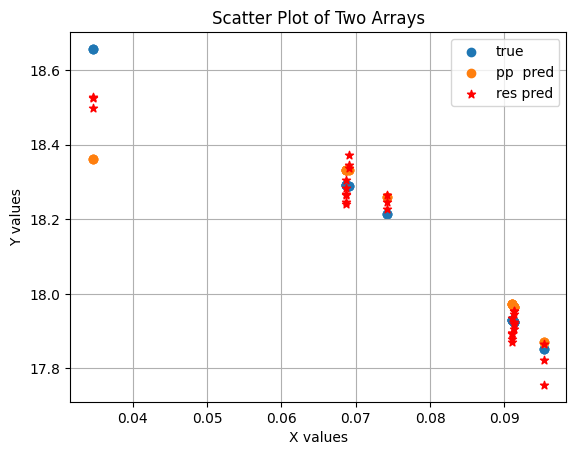

In [5]:


indicies = torch.where(neigh_atom == 12)
pred = all_pred[indicies]
dis = all_dis[indicies]
true = all_true[indicies]
res = res_pred[indicies]

import matplotlib.pyplot as plt
import numpy as np

# 创建两个一维数组
x = dis
y = true
z = pred

# 绘制散点图
plt.scatter(x,y,label="true")
plt.scatter(x,z,label='pp  pred')
#plt.scatter(x, y-z, c='blue', marker='o')
plt.scatter(x, res, c='r', marker='*',label='res pred')

# 添加标题和标签
plt.title('Scatter Plot of Two Arrays')
plt.xlabel('X values')
plt.ylabel('Y values')

# 显示图形
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
res

In [6]:
import math
import logging
import time

from model import E3DensityModel, ResidualCorrectionModel

from torch.utils.data.dataloader import DataLoader

import torch

import glob
import os
import numpy as np
from tqdm import  tqdm
from torch.utils.data import DataLoader, random_split, Subset
# from torch.utils.data import DataLoader
from ase.db import connect
from utils_see_chg import DensityData, MyCollator
from transformers import AdamW, get_scheduler

random_seed = 42
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)


device = 'cuda:7'

model = E3DensityModel()
new_model = E3DensityModel()
res_model = ResidualCorrectionModel(num_embeddings=300, embedding_dim=128)

num_train_epochs = 300


# dict_test = {'atom_edges_displacement': torch.zeros(1 , 50, 3),
#              'num_atom_edges': torch.tensor(10).long().unsqueeze(0),
#              'num_nodes': torch.tensor(5).long().unsqueeze(0),
#              'atom_edges': torch.zeros(1, 50, 2).long(),
#              'atom_xyz': torch.zeros(1, 5, 3),
#              'nodes': torch.ones(5).long().unsqueeze(0),
#              'cell': torch.zeros(1, 3, 3),
#              'probe_xyz': torch.zeros(1, 500, 3),
#              'num_probes': torch.tensor(500).long().unsqueeze(0),
#              'probe_edges_displacement': torch.zeros(1, 500, 3),
#              'num_probe_edges': torch.tensor(500).long().unsqueeze(0),
#              'probe_edges': torch.zeros(1, 500, 2).long()
#              }


#mysql_url= 'mysql://root:@localhost:3306/temp_chg'
mysql_url = "quick.db"
dataset = DensityData(mysql_url)

# total_count = len(dataset)
# print(f"Total count: {total_count}")
# train_count = int(0.8 * total_count)
# valid_count = int(0.1 * total_count)
# test_count = total_count - train_count - valid_count
# train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_count, valid_count, test_count])

# Access the last item from the test dataset
# last_index = test_dataset.indices[-4]
# last_example = dataset[last_index]


checkpoint = torch.load('/data/chg/charge3net-main-suth/checkpoints/xrd_best.pt', map_location='cpu')  # 加载 .pt 文件
model.load_state_dict(checkpoint)
model = model.to(device)

# checkpoint = torch.load('/data/chg/charge3net-main/models/charge3net_mp.pt', map_location='cpu')  # 加载 .pt 文件
# model.load_state_dict(checkpoint['model'])
# model = model.to(device)




checkpoint = torch.load('/data/chg/charge3net-main-suth/checkpoints_res/res_best.pt', map_location='cpu')  # 加载 .pt 文件
# print(checkpoint.keys())
res_model.load_state_dict(checkpoint)

res_model = res_model.to(device)



checkpoint = torch.load('/data/chg/charge3net-main-suth/checkpoints_res/res_best_model.pt', map_location='cpu')  # 加载 .pt 文件
# print(checkpoint.keys())
new_model.load_state_dict(checkpoint)

new_model = new_model.to(device)

# valid_dataset = dataset

# val_dataloader = DataLoader(
#         #[valid_dataset],
#         [valid_dataset[:10]],
#         batch_size=1,
#         num_workers=0,
#         collate_fn=MyCollator(mysql_url, cutoff=4, num_probes=None))

checkpoint directory created: ./model
saving model version 0.0
len db 2


In [11]:
all_true = []
all_pred = []
all_true_corr = []
all_pred_corr = []
countt = 0
valid_dataset = dataset

val_dataloader = DataLoader(
        #[valid_dataset],
        valid_dataset,
        batch_size=1,
        num_workers=0,
        collate_fn=MyCollator(mysql_url, cutoff=4, num_probes=None))
with torch.no_grad():
    for step, (big_batch, big_batch_invalid) in enumerate(val_dataloader):
        for batch in tqdm(big_batch, total=len(big_batch)):
            batch = {k: v.to(device) for k, v in batch.items()}
            output_old, _ = model(batch)
            output_old = output_old.view(-1)
            output, node_rep = new_model(batch)
            output = output.view(-1)
            res, _ = res_model(batch, node_rep)
            tru = batch['probe_target'].view(-1)
            all_true.append(tru.detach().cpu())
            all_pred.append(output_old.detach().cpu())
            #all_pred_corr.append(output.detach().cpu() + 1.0 * res.view(-1).detach().cpu())
            all_pred_corr.append(res.view(-1).detach().cpu())

        for batch in tqdm(big_batch_invalid, total=len(big_batch_invalid)):
            batch = {k: v.to(device) for k, v in batch.items()}
            output, _ = model(batch)
            output = output.view(-1)
            tru = batch['probe_target'].view(-1)
            all_true.append(tru.detach().cpu())
            all_pred.append(output.detach().cpu())
            all_pred_corr.append(output.detach().cpu())


# val_dataloader = DataLoader(
#         #[valid_dataset],
#         [valid_dataset[-1]],
#         batch_size=1,
#         num_workers=0,
#         collate_fn=MyCollator(mysql_url, cutoff=4, num_probes=None))
# with torch.no_grad():
#     for step, (big_batch, big_batch_invalid) in enumerate(val_dataloader):
#         for batch in tqdm(big_batch, total=len(big_batch)):
#             batch = {k: v.to(device) for k, v in batch.items()}
#             output_old, _ = model(batch)
#             output_old = output_old.view(-1)
#             output, node_rep = new_model(batch)
#             output = output.view(-1)
#             res, _ = res_model(batch, node_rep)
#             tru = batch['probe_target'].view(-1)
#             all_true.append(tru.detach().cpu())
#             all_pred.append(output_old.detach().cpu())
#             #all_pred_corr.append(output.detach().cpu() + 1.0 * res.view(-1).detach().cpu())
#             all_pred_corr.append(res.view(-1).detach().cpu())

#         for batch in tqdm(big_batch_invalid, total=len(big_batch_invalid)):
#             batch = {k: v.to(device) for k, v in batch.items()}
#             output, _ = model(batch)
#             output = output.view(-1)
#             tru = batch['probe_target'].view(-1)
#             all_true.append(tru.detach().cpu())
#             all_pred.append(output.detach().cpu())
#             all_pred_corr.append(output.detach().cpu())




from sklearn.metrics import r2_score, mean_absolute_error
all_true = torch.cat(all_true, dim=0).numpy()
all_pred = torch.cat(all_pred, dim=0).numpy()
# all_true_corr = torch.cat(all_true_corr, dim=0).numpy()
all_pred_corr = torch.cat(all_pred_corr, dim=0).numpy()

1


100%|██████████| 84/84 [00:34<00:00,  2.40it/s]


2


100%|██████████| 84/84 [00:22<00:00,  3.67it/s]


In [9]:
# # 确保列表长度是偶数
# assert len(all_true) % 2 == 0
# assert len(all_pred) % 2 == 0
# assert len(all_pred_corr) % 2 == 0

# # 初始化新的列表来存储合并后的数据
# all_true_avg = []
# all_pred_avg = []
# all_pred_corr_avg = []

# # 遍历列表，每次处理两个元素
# for i in range(0, len(all_true), 2):
#     # 将两个样本的真实值相加并除以二
#     true_avg = (all_true[i] + all_true[i+1]) / 2
#     all_true_avg.append(true_avg)
    
#     # 将两个样本的预测值相加并除以二
#     pred_avg = (all_pred[i] + all_pred[i+1]) / 2
#     all_pred_avg.append(pred_avg)
    
#     # 将两个样本的校正预测值相加并除以二
#     pred_corr_avg = (all_pred_corr[i] + all_pred_corr[i+1]) / 2
#     all_pred_corr_avg.append(pred_corr_avg)

# # 现在all_true_avg, all_pred_avg, all_pred_corr_avg包含了合并后的数据

In [12]:
all_true_avg,all_pred_avg,all_pred_corr_avg = all_true,all_pred, all_pred

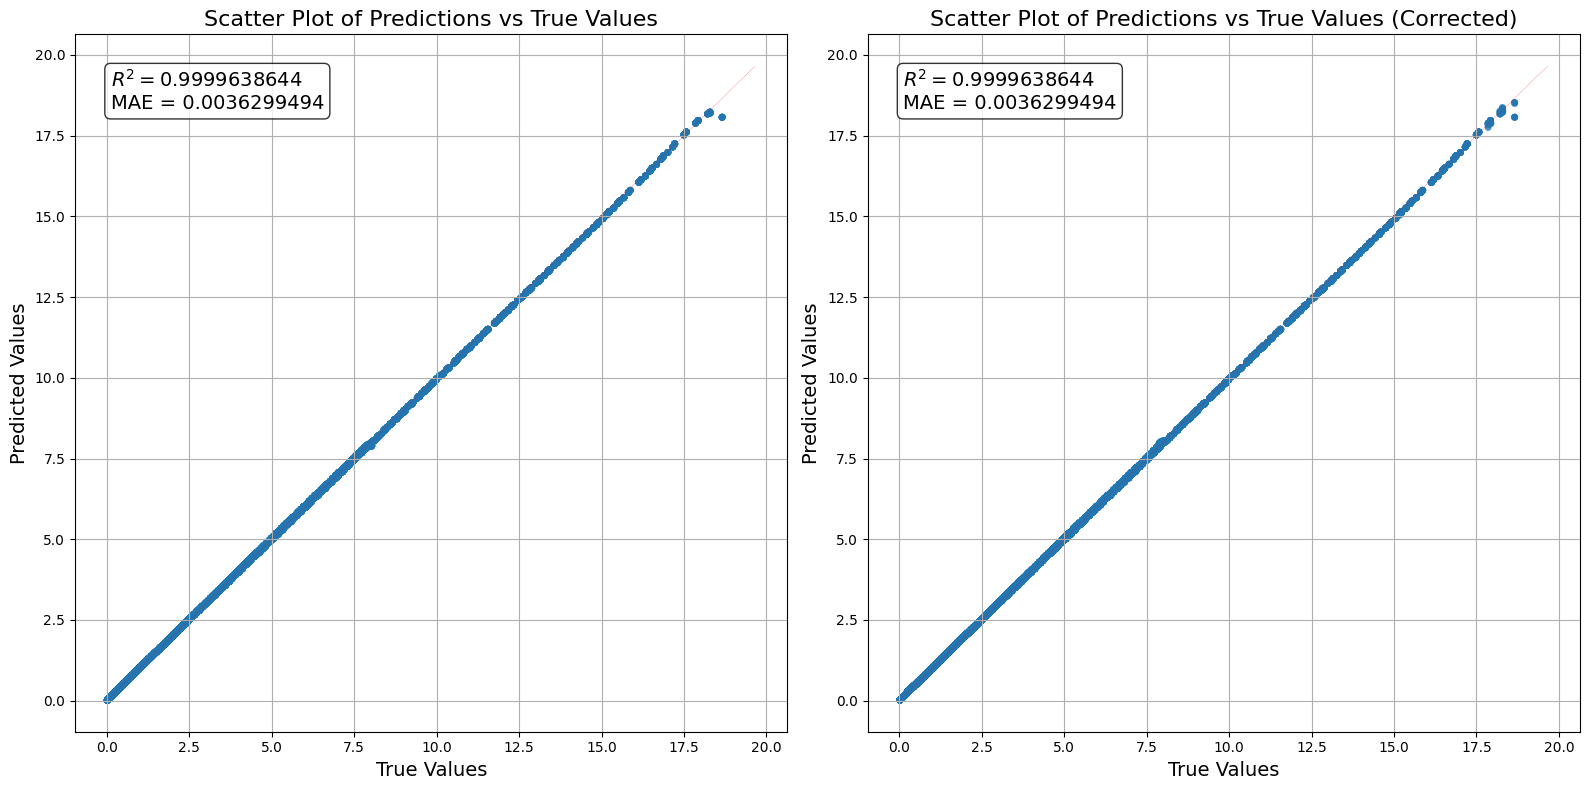

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error




# 假设all_true, all_pred, all_pred_corr已经定义
r2 = r2_score(all_true_avg, all_pred_avg)
mae = mean_absolute_error(all_true_avg, all_pred_avg)

r2_corr = r2_score(all_true_avg, all_pred_corr_avg)
mae_corr = mean_absolute_error(all_true_avg, all_pred_corr_avg)

# 创建1行2列的子图布局
fig, axs = plt.subplots(1, 2, figsize=(16, 8))  # 调整figsize以适应两个子图

# 第一个子图
axs[0].scatter(all_true, all_pred, alpha=0.5, s=25, edgecolors='none')
axs[0].plot([all_true.min(), all_true.max()+1], [all_true.min(), all_true.max()+1], 'r--', lw=0.2)
axs[0].text(0.05, 0.95, f"$R^2 = {r2:.10f}$\nMAE = {mae:.10f}", transform=axs[0].transAxes, 
            fontsize=14, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
axs[0].set_xlabel('True Values', fontsize=14)
axs[0].set_ylabel('Predicted Values', fontsize=14)
axs[0].set_title('Scatter Plot of Predictions vs True Values', fontsize=16)
axs[0].grid(True)

# 第二个子图
axs[1].scatter(all_true, all_pred_corr, alpha=0.5, s=25, edgecolors='none')
axs[1].plot([all_true.min(), all_true.max()+1], [all_true.min(), all_true.max()+1], 'r--', lw=0.2)
axs[1].text(0.05, 0.95, f"$R^2 = {r2_corr:.10f}$\nMAE = {mae_corr:.10f}", transform=axs[1].transAxes, 
            fontsize=14, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
axs[1].set_xlabel('True Values', fontsize=14)
axs[1].set_ylabel('Predicted Values', fontsize=14)
axs[1].set_title('Scatter Plot of Predictions vs True Values (Corrected)', fontsize=16)
axs[1].grid(True)

# 调整子图间距
plt.tight_layout()

# 保存图片
plt.savefig('scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

import matplotlib.pyplot as plt
r2 = r2_score(all_true, all_pred)
mae = mean_absolute_error(all_true, all_pred)

r2_corr = r2_score(all_true, all_pred_corr)
mae_corr = mean_absolute_error(all_true, all_pred_corr)
# r2_corr = r2_score(all_true_corr, all_pred_corr)
# mae_corr = mean_absolute_error(all_true_corr, all_pred_corr)


print(f"R² (R-squared): {r2:.10f}, R²_corr (R-squared): {r2_corr:.10f}")
print(f"MAE (Mean Absolute Error): {mae:.10f}, MAE_corr (Mean Absolute Error): {mae_corr:.10f}")


# 绘制散点图
plt.figure(figsize=(8, 8))
plt.scatter(all_true, all_pred, alpha=0.3, s=5, edgecolors='none')
plt.plot([all_true.min(), all_true.max()+1], [all_true.min(), all_true.max()+1], 'r--', lw=0.2)

# 显示R²和MAE
plt.text(0.05, 0.95, f"$R^2 = {r2:.10f}$\nMAE = {mae:.10f}", transform=plt.gca().transAxes, 
         fontsize=14, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.xlabel('True Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.title('Scatter Plot of Predictions vs True Values', fontsize=16)
plt.grid(True)

# 保存图片
plt.savefig('scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(8, 8))
plt.scatter(all_true, all_pred_corr, alpha=0.3, s=5, edgecolors='none')
plt.plot([all_true.min(), all_true.max()+1], [all_true.min(), all_true.max()+1], 'r--', lw=0.2)

# 显示R²和MAE
plt.text(0.05, 0.95, f"$R^2 = {r2_corr:.10f}$\nMAE = {mae_corr:.10f}", transform=plt.gca().transAxes, 
         fontsize=14, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.xlabel('True Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.title('Scatter Plot of Predictions vs True Values', fontsize=16)
plt.grid(True)

# 保存图片
plt.savefig('scatter_plot_corr.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(res)